# 是时候获取二阶SVF的了
先把svf的多模式输出时的传递函数搞出来  
没记错的话是 LP + 2ζBP + HP = X  

In [80]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy.signal as signal

In [11]:
# ==========================================
# Sympy 推导 模拟SvfTPT 传递函数
# ==========================================
# 1. 定义符号
# s: 拉普拉斯算子
# g: 替代 omega_0 的频率/步长参数, zeta: 阻尼系数
# m0, m1, m2: 分别为 LP, BP, HP 的混合权重
s, g, zeta = sp.symbols('s g zeta', positive=True)
m0, m1, m2 = sp.symbols('m_0 m_1 m_2')

# 2. 建立模拟域 SVF 的控制方程（使用 g 代替 omega_0）
Vhp, Vbp, Vlp, X = sp.symbols('V_hp V_bp V_lp X')

# 模拟拓扑：
# Vhp = X - 2*zeta*Vbp - Vlp
# Vbp = (g / s) * Vhp
# Vlp = (g / s) * Vbp
eq1 = sp.Eq(Vhp, X - 2 * zeta * Vbp - Vlp)
eq2 = sp.Eq(Vbp, (g / s) * Vhp)
eq3 = sp.Eq(Vlp, (g / s) * Vbp)

# 3. 求解各输出端
solutions = sp.solve([eq1, eq2, eq3], (Vhp, Vbp, Vlp))

H_hp = (solutions[Vhp] / X).simplify()
H_bp = (solutions[Vbp] / X).simplify()
H_lp = (solutions[Vlp] / X).simplify()

# 4. 线性组合: H(s) = m0*LP + m1*BP + m2*HP
H_total = m0 * H_lp + m1 * H_bp + m2 * H_hp

# 5. 化简与整理
H_total_combined = sp.cancel(H_total)
H_svf2_analog = sp.collect(H_total_combined, s)
display(H_svf2_analog)

(g**2*m_0 + g*m_1*s + m_2*s**2)/(g**2 + 2*g*s*zeta + s**2)

In [12]:
# ==========================================
# Sympy 推导 数字SvfTPT 传递函数
# ==========================================
# g = tan(w/2),  g1 = 2*zeta + g,  d = 1 / (1 + 2*zeta*g + g^2)
# hp = (x - g1*s1 - s2) * d
# v1 = g * hp,  bp = v1 + s1
# v2 = g * bp,  lp = v2 + s2
# s1 <- bp + v1,  s2 <- lp + v2
# out = m0*lp + m1*bp + m2*hp
# 其中 r2 = 2*zeta

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

sym_zeta, sym_g, sym_d, sym_m0, sym_m1, sym_m2, sym_z = sp.symbols('zeta g d m0 m1 m2 z')
sym_X, sym_S1, sym_S2, sym_Hp, sym_Bp, sym_Lp = sp.symbols('X S1 S2 Hp Bp Lp')

sym_V1 = sym_g * sym_Hp
sym_V2 = sym_g * sym_Bp

sym_eqs = [
    sp.Eq(sym_Hp, (sym_X - (2*sym_zeta + sym_g)*sym_S1 - sym_S2) * sym_d),
    sp.Eq(sym_Bp, sym_V1 + sym_S1),
    sp.Eq(sym_Lp, sym_V2 + sym_S2),
    sp.Eq(sym_z * sym_S1, sym_Bp + sym_V1),
    sp.Eq(sym_z * sym_S2, sym_Lp + sym_V2),
    sp.Eq(sp.Symbol('Out'), sym_m0*sym_Lp + sym_m1*sym_Bp + sym_m2*sym_Hp),
]

sym_sol = sp.solve(sym_eqs, [sym_Hp, sym_Bp, sym_Lp, sym_S1, sym_S2, sp.Symbol('Out')], dict=True)[0]
sym_H = sp.simplify(sym_sol[sp.Symbol('Out')] / sym_X)

sym_H_d = sp.simplify(sym_H.subs(sym_d, 1 / (1 + 2*sym_zeta*sym_g + sym_g*sym_g)))
sym_num, sym_den = sp.fraction(sp.together(sym_H_d))
sym_H_svf2_digital = sp.collect(sp.expand(sym_num), sym_z) / sp.collect(sp.expand(sym_den), sym_z)
display(sym_H_svf2_digital)

(g**2*m0 - g*m1 + m2 + z**2*(g**2*m0 + g*m1 + m2) + z*(2*g**2*m0 - 2*m2))/(g**2 - 2*g*zeta + z**2*(g**2 + 2*g*zeta + 1) + z*(2*g**2 - 2) + 1)

**数字域** (z 为前向移位算子 $z \cdot x[n] = x[n+1]$):

$$ H(z) = \frac{
g^{2} m_{0} - g m_{1} + m_{2}
+ z^{2} (g^{2} m_{0} + g m_{1} + m_{2})
+ z (2 g^{2} m_{0} - 2 m_{2})
}{
g^{2} - 2 g \zeta + 1
+ z^{2} (g^{2} + 2 g \zeta + 1)
+ z (2 g^{2} - 2)
} $$

等价 $z^{-1}$ 形式（$d = 1/(g^{2} + 2 g \zeta + 1)$）:

$$ H(z^{-1}) = \frac{
(g^{2} m_{0} + g m_{1} + m_{2})
+ (2 g^{2} m_{0} - 2 m_{2}) z^{-1}
+ (g^{2} m_{0} - g m_{1} + m_{2}) z^{-2}
}{
1 + (2 g^{2} - 2) d \cdot z^{-1} + (g^{2} - 2 g \zeta + 1) d \cdot z^{-2}
} $$

**模拟域**:

$$ H(s) = \frac{g^{2} m_{0} + g m_{1} s + m_{2} s^{2}}{g^{2} + 2 g \zeta s + s^{2}} $$

> LP: $m_0=1,m_1=0,m_2=0$ | BP: $m_0=0,m_1=2\zeta,m_2=0$ | HP: $m_0=0,m_1=0,m_2=1$

验证一下传递函数正不正确


C:\Users\Kawai\AppData\Local\Temp\ipykernel_43180\29430654.py:144: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


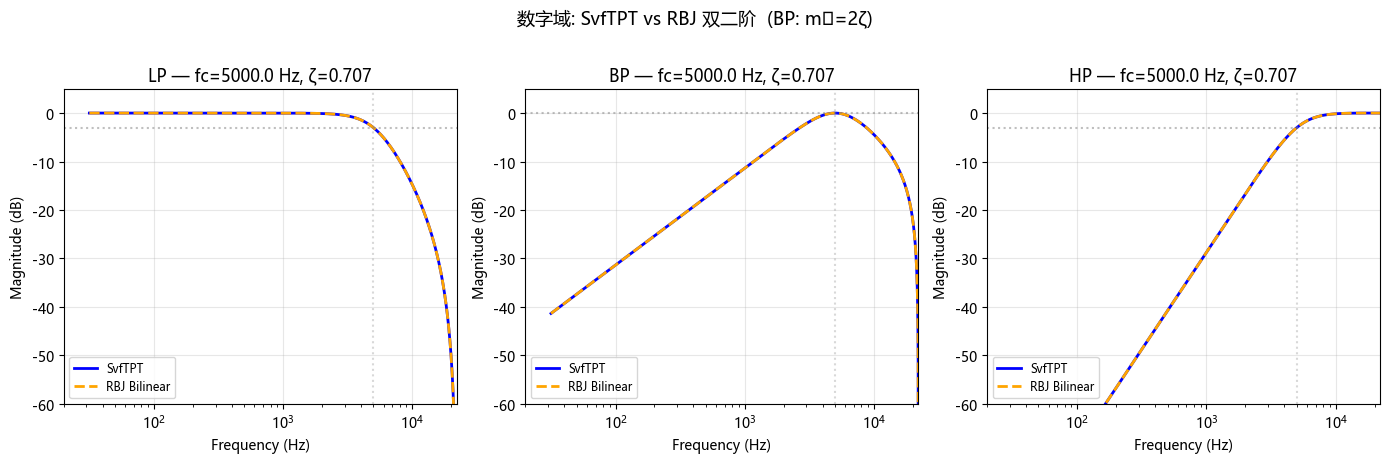

C:\Users\Kawai\AppData\Local\Temp\ipykernel_43180\29430654.py:201: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\Kawai\AppData\Local\Temp\ipykernel_43180\29430654.py:201: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\Kawai\AppData\Local\Temp\ipykernel_43180\29430654.py:201: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


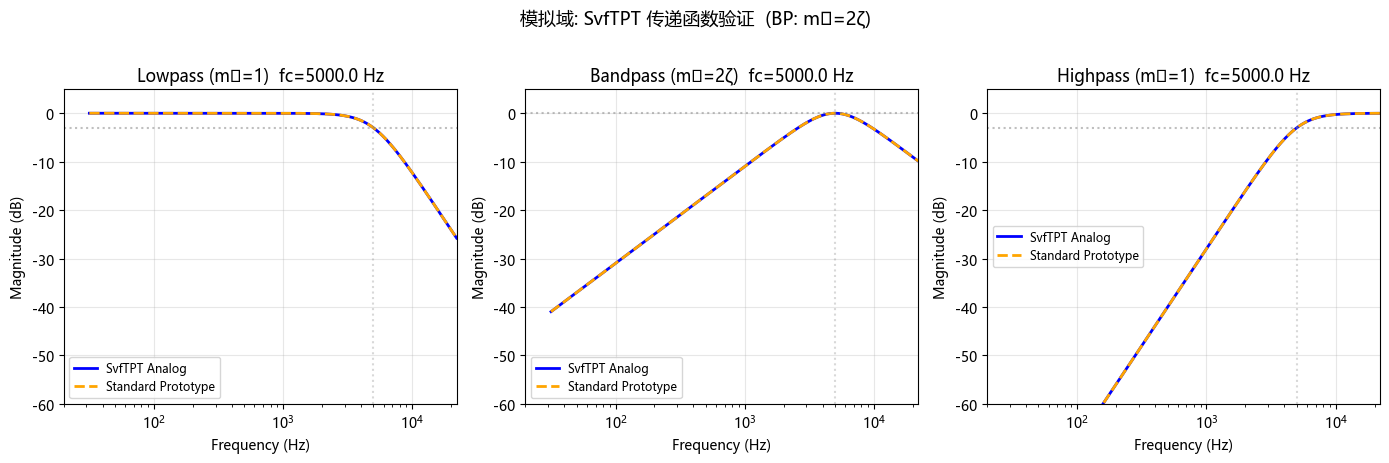

In [13]:
def get_rbj_coefficients(filter_type, fc, fs, zeta=1.0/np.sqrt(2), gain_db=10.0):
    """
    计算标准 RBJ (Robert Bristow-Johnson) 双二阶滤波器系数。
    基于 Audio EQ Cookbook，使用双线性变换 + 频率预扭曲。
    """
    w0 = 2.0 * np.pi * fc / fs   # 归一化角频率
    cos_w0 = np.cos(w0)
    sin_w0 = np.sin(w0)
    Q = 1.0 / (2.0 * zeta)       # 品质因数 Q ↔ 阻尼系数 ζ
    alpha = sin_w0 / (2.0 * Q)   # RBJ alpha 参数
    A = 10.0 ** (gain_db / 40.0) # RBJ 增益参数 (注意是 dB/40)

    if filter_type.lower() in ["low pass", "lp"]:
        b0 = (1.0 - cos_w0) / 2.0; b1 = 1.0 - cos_w0; b2 = (1.0 - cos_w0) / 2.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["high pass", "hp"]:
        b0 = (1.0 + cos_w0) / 2.0; b1 = -(1.0 + cos_w0); b2 = (1.0 + cos_w0) / 2.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band pass", "bp"]:
        b0 = alpha; b1 = 0.0; b2 = -alpha
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band stop", "notch"]:
        b0 = 1.0; b1 = -2.0 * cos_w0; b2 = 1.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["all pass", "ap"]:
        b0 = 1.0 - alpha; b1 = -2.0 * cos_w0; b2 = 1.0 + alpha
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band shelf", "peak"]:
        b0 = 1.0 + alpha * A; b1 = -2.0 * cos_w0; b2 = 1.0 - alpha * A
        a0 = 1.0 + alpha / A; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha / A
    elif filter_type.lower() in ["low shelf", "ls"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = 2.0 * A * ((A - 1.0) - (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = -2.0 * ((A - 1.0) + (A + 1.0) * cos_w0)
        a2 = (A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    elif filter_type.lower() in ["high shelf", "hs"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = -2.0 * A * ((A - 1.0) + (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = 2.0 * ((A - 1.0) - (A + 1.0) * cos_w0)
        a2 = (A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")

    # 归一化使 a0 = 1
    b = [b0 / a0, b1 / a0, b2 / a0]
    a = [1.0, a1 / a0, a2 / a0]
    return b, a

def get_analogue_magnitude_response(filter_type, f, fc, zeta=1.0/np.sqrt(2), gain_db=10.0):
    """计算二阶模拟原型在频率 f (Hz) 处的幅频响应 (绝对值)"""
    s = 1j * (f / fc)
    g = 10 ** (gain_db / 20.0)
    sg = np.sqrt(g)        # 10^(db/40), 参考中的 A
    fg = np.sqrt(sg)       # 10^(db/80), 参考中的 sqrt_A
    
    if filter_type.lower() in ["low pass", "lp"]:
        h_s = 1.0 / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["high pass", "hp"]:
        h_s = s**2 / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band pass", "bp"]:
        h_s = 2*zeta*s / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band stop", "notch"]:
        h_s = (s**2 + 1.0) / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["all pass", "ap"]:
        h_s = (s**2 - 2*zeta*s + 1.0) / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band shelf", "peak"]:
        h_s = (s**2 + 2*zeta*sg*s + 1.0) / (s**2 + 2*zeta/sg*s + 1.0)
    elif filter_type.lower() in ["high shelf", "hs"]:
        # H(s) = A * (A*s² + sqrt_A/Q*s + 1) / (s² + sqrt_A/Q*s + A)
        # A = sg, sqrt_A = fg, Q = 1/(2*zeta)
        h_s = sg * (sg*s**2 + fg*2*zeta*s + 1.0) / (s**2 + fg*2*zeta*s + sg)
    elif filter_type.lower() in ["low shelf", "ls"]:
        # H(s) = A * (s² + sqrt_A/Q*s + A) / (A*s² + sqrt_A/Q*s + 1)
        h_s = sg * (s**2 + fg*2*zeta*s + sg) / (sg*s**2 + fg*2*zeta*s + 1.0)
    else:
        return np.ones_like(f)
        
    return np.abs(h_s)

# ============================================================
# 数字 SvfTPT 传递函数验证 (与 RBJ 对比)
# ============================================================
# 由 cell 18 sympy 推导:
#   H(z) = (b0 + b1·z⁻¹ + b2·z⁻²) / (1 + a1·z⁻¹ + a2·z⁻²)
#   den = (g²+2gζ+1) + (2g²-2)·z⁻¹ + (g²-2gζ+1)·z⁻²
#   num = (g²m0+gm1+m2) + (2g²m0-2m2)·z⁻¹ + (g²m0-gm1+m2)·z⁻²
# BP 使用 m₁=2ζ 以匹配标准原型 (H_bp = 2ζ·s_norm / (s_norm²+2ζ·s_norm+1))

fs = 44100.0
fc = 5000.0
zeta = 1.0 / np.sqrt(2)

w0 = 2 * np.pi * fc / fs
g = np.tan(w0 / 2)
d = 1.0 / (1.0 + 2 * zeta * g + g * g)

# 分母相同
a = [1.0, (2 * g * g - 2) * d, (g * g - 2 * zeta * g + 1) * d]

# 三种类型的分子系数 (BP: m₁=2ζ)
b_lp = [g * g * d,  2 * g * g * d,              g * g * d]       # m0=1,m1=0,  m2=0
b_bp = [2*zeta*g*d, 0,                         -2*zeta*g*d]      # m0=0,m1=2ζ, m2=0
b_hp = [d,          -2 * d,                     d]                # m0=0,m1=0,  m2=1

types = ["LP", "BP", "HP"]
bs = [b_lp, b_bp, b_hp]
rbj_types = ["low pass", "band pass", "high pass"]

w_grid = np.logspace(1.5, np.log10(fs / 2), 2048)
w_norm, _ = signal.freqz([1], [1], worN=w_grid, fs=fs)  # 只是为了得到频率轴

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for col, (t, b, rbj_t) in enumerate(zip(types, bs, rbj_types)):
    ax = axes[col]
    _, h_svf = signal.freqz(b, a, worN=w_norm, fs=fs)
    b_rbj, a_rbj = get_rbj_coefficients(rbj_t, fc, fs, zeta)
    _, h_rbj = signal.freqz(b_rbj, a_rbj, worN=w_norm, fs=fs)

    ax.semilogx(w_norm, 20 * np.log10(np.maximum(np.abs(h_svf), 1e-5)),
                'b-', label='SvfTPT', linewidth=2)
    ax.semilogx(w_norm, 20 * np.log10(np.maximum(np.abs(h_rbj), 1e-5)),
                'orange', linestyle='--', label='RBJ Bilinear', linewidth=2)
    # BP 峰值在 fc 处为 0dB, LP/HP 在 fc 处为 -3dB
    ref_db = 0 if col == 1 else -3
    ax.axhline(ref_db, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(fc, color='gray', linestyle=':', alpha=0.3)
    ax.set_xscale('log')
    ax.set_xlim(20, fs / 2)
    ax.set_ylim(-60, 5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{t} — fc={fc} Hz, ζ={zeta:.3f}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.legend(fontsize='small')

fig.suptitle('数字域: SvfTPT vs RBJ 双二阶  (BP: m₁=2ζ)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 模拟 SvfTPT 传递函数验证 (与标准模拟原型对比)
# ============================================================
# 由 cell 20 sympy 推导:
#   H(s) = (m0·g² + m1·g·s + m2·s²) / (s² + 2ζ·g·s + g²)
# 令 g = ω₀, s = jω:
#   LP: g² / (s² + 2ζgs + g²)          (m₀=1)
#   BP: 2ζ·g·s / (s² + 2ζgs + g²)      (m₁=2ζ)
#   HP: s² / (s² + 2ζgs + g²)           (m₂=1)

fc_svf = 5000.0
zeta_svf = 1.0 / np.sqrt(2)
g_svf = 2 * np.pi * fc_svf  # g = ω₀

freq = np.logspace(1.5, np.log10(fs / 2), 4096)
s = 1j * 2 * np.pi * freq

# SvfTPT 模拟传递函数 (BP: m₁=2ζ)
H_lp_svf = g_svf**2 / (s**2 + 2 * zeta_svf * g_svf * s + g_svf**2)                          # m0=1
H_bp_svf = (2 * zeta_svf * g_svf * s) / (s**2 + 2 * zeta_svf * g_svf * s + g_svf**2)         # m1=2ζ
H_hp_svf = s**2 / (s**2 + 2 * zeta_svf * g_svf * s + g_svf**2)                               # m2=1

# 标准模拟原型 (归一化 s_norm = j·f/fc)
H_lp_ref = get_analogue_magnitude_response("low pass", freq, fc_svf, zeta=zeta_svf)
H_bp_ref = get_analogue_magnitude_response("band pass", freq, fc_svf, zeta=zeta_svf)
H_hp_ref = get_analogue_magnitude_response("high pass", freq, fc_svf, zeta=zeta_svf)

svf_mags = [H_lp_svf, H_bp_svf, H_hp_svf]
ref_mags = [H_lp_ref, H_bp_ref, H_hp_ref]
titles  = ["Lowpass (m₀=1)", "Bandpass (m₁=2ζ)", "Highpass (m₂=1)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for col, (svf_h, ref_h, title) in enumerate(zip(svf_mags, ref_mags, titles)):
    ax = axes[col]
    ax.semilogx(freq, 20 * np.log10(np.maximum(np.abs(svf_h), 1e-15)),
                'b-', label='SvfTPT Analog', linewidth=2)
    ax.semilogx(freq, 20 * np.log10(np.maximum(ref_h, 1e-15)),
                'orange', linestyle='--', label='Standard Prototype', linewidth=2)
    # BP 峰值在 fc 处为 0dB, LP/HP 在 fc 处为 -3dB
    ref_db = 0 if col == 1 else -3
    ax.axhline(ref_db, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(fc_svf, color='gray', linestyle=':', alpha=0.3)
    ax.set_xscale('log')
    ax.set_xlim(20, fs / 2)
    ax.set_ylim(-60, 5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{title}  fc={fc_svf} Hz')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.legend(fontsize='small')

fig.suptitle('模拟域: SvfTPT 传递函数验证  (BP: m₁=2ζ)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 现在是时候推导数字svf的参数和混合系数了
和一阶一样先推导分母部分

In [18]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

In [20]:
# ==========================================
# Sympy 推导 模拟SvfTPT 传递函数
# ==========================================
# 1. 定义符号
# s: 拉普拉斯算子
# a_g: 模拟截止角频率 omega_0
# a_zeta: 模拟阻尼系数
# a_m0, a_m1, a_m2: 分别为 LP, BP, HP 的混合权重
s, a_g, a_zeta = sp.symbols('s g zeta', positive=True)
a_m0, a_m1, a_m2 = sp.symbols('m0 m1 m2', real=True)

# 2. 建立模拟域 SVF 的控制方程（使用 a_g 代替 omega_0）
Vhp, Vbp, Vlp, X = sp.symbols('V_hp V_bp V_lp X')

# 模拟拓扑：
# Vhp = X - 2*a_zeta*Vbp - Vlp
# Vbp = (a_g / s) * Vhp
# Vlp = (a_g / s) * Vbp
eq1 = sp.Eq(Vhp, X - 2 * a_zeta * Vbp - Vlp)
eq2 = sp.Eq(Vbp, (a_g / s) * Vhp)
eq3 = sp.Eq(Vlp, (a_g / s) * Vbp)

# 3. 求解各输出端
solutions = sp.solve([eq1, eq2, eq3], (Vhp, Vbp, Vlp))

H_hp = (solutions[Vhp] / X).simplify()
H_bp = (solutions[Vbp] / X).simplify()
H_lp = (solutions[Vlp] / X).simplify()

# 4. 线性组合: H(s) = a_m0*LP + a_m1*BP + a_m2*HP
H_total = a_m0 * H_lp + a_m1 * H_bp + a_m2 * H_hp

# 5. 化简与整理
H_total_combined = sp.cancel(H_total)
H_svf2_analog = sp.collect(H_total_combined, s)
display(H_svf2_analog)

(g**2*m0 + g*m1*s + m2*s**2)/(g**2 + 2*g*s*zeta + s**2)

In [34]:
# ==========================================
# Sympy 推导 数字SvfTPT 传递函数
# ==========================================
# d_g未知,  g1 = 2*d_zeta(未知) + d_g,  d = 1 / (1 + 2*d_zeta*d_g + d_g^2)
# hp = (x - g1*s1 - s2) * d
# v1 = d_g * hp,  bp = v1 + s1
# v2 = d_g * bp,  lp = v2 + s2
# s1 <- bp + v1,  s2 <- lp + v2
# out = d_m0(未知)*lp + d_m1(未知)*bp + d_m2(未知)*hp
# 其中 r2 = 2*d_zeta

d_zeta, d_g, d_d, d_m0, d_m1, d_m2, d_z = sp.symbols('zeta_z g_z d m_0z m_1z m_2z z')
d_X, d_S1, d_S2, d_Hp, d_Bp, d_Lp = sp.symbols('X S1 S2 Hp Bp Lp')

d_V1 = d_g * d_Hp
d_V2 = d_g * d_Bp

d_eqs = [
    sp.Eq(d_Hp, (d_X - (2*d_zeta + d_g)*d_S1 - d_S2) * d_d),
    sp.Eq(d_Bp, d_V1 + d_S1),
    sp.Eq(d_Lp, d_V2 + d_S2),
    sp.Eq(d_z * d_S1, d_Bp + d_V1),
    sp.Eq(d_z * d_S2, d_Lp + d_V2),
    sp.Eq(sp.Symbol('Out'), d_m0*d_Lp + d_m1*d_Bp + d_m2*d_Hp),
]

d_sol = sp.solve(d_eqs, [d_Hp, d_Bp, d_Lp, d_S1, d_S2, sp.Symbol('Out')], dict=True)[0]
d_H = sp.simplify(d_sol[sp.Symbol('Out')] / d_X)

d_H_d = sp.simplify(d_H.subs(d_d, 1 / (1 + 2*d_zeta*d_g + d_g*d_g)))
d_num, d_den = sp.fraction(sp.together(d_H_d))
d_H_svf2_digital = sp.collect(sp.expand(d_num), d_z) / sp.collect(sp.expand(d_den), d_z)
display(d_H_svf2_digital)

(g_z**2*m_0z - g_z*m_1z + m_2z + z**2*(g_z**2*m_0z + g_z*m_1z + m_2z) + z*(2*g_z**2*m_0z - 2*m_2z))/(g_z**2 - 2*g_z*zeta_z + z**2*(g_z**2 + 2*g_z*zeta_z + 1) + z*(2*g_z**2 - 2) + 1)

## 先推导分母，准确来说是 积分器增益g和zeta

In [35]:
# 1. 定义自变量与常数符号
# 根据图像内容：x, y 为自变量，sigma (σ) 为正的常数
x, y = sp.symbols('x y', real=True)
sigma = sp.symbols('sigma', positive=True)

# 2. 定义中间函数 nu(x, y) 和 kappa(x, y)
# nu(x, y) = sqrt(x^4 + 2 * x^2 * sigma^2 * (2 * y^2 - 1) + sigma^4)
# nu = sp.sqrt(x**4 + 2 * x**2 * sigma**2 * (2 * y**2 - 1) + sigma**4)

# kappa(x, y) = x^2 * (2 * y^2 - 1) + sigma^2
# kappa = x**2 * (2 * y**2 - 1) + sigma**2

nu, kappa = sp.symbols('v, k')

# 3. 定义 phi_1(x, y) 和 phi_2(x, y) 的共有子项
# 观察发现分母中都含有：pi^2 + pi * sqrt(2) * sqrt(nu + kappa) + nu
common_sqrt = sp.sqrt(nu + kappa)
denom = sp.pi**2 + sp.pi * sp.sqrt(2) * common_sqrt + nu

# 4. 构建 phi_1(x, y) 和 phi_2(x, y) 的完整表达式
phi_1 = (2 * sp.pi**2 - 2 * nu) / denom
phi_2 = (sp.pi**2 - sp.pi * sp.sqrt(2) * common_sqrt + nu) / denom

print("phi1=")
display(phi_1)
print("phi2=")
display(phi_2)

phi1=


(-2*v + 2*pi**2)/(v + sqrt(2)*pi*sqrt(k + v) + pi**2)

phi2=


(v - sqrt(2)*pi*sqrt(k + v) + pi**2)/(v + sqrt(2)*pi*sqrt(k + v) + pi**2)

In [36]:
num, den = sp.fraction(sp.together(d_H_svf2_digital))
# 分母多项式系数 (z 域前向)
poly = sp.Poly(sp.expand(den), d_z)
coeffs = poly.all_coeffs()  # [z²系数, z¹系数, z⁰系数]

svf_a1 = coeffs[1] / coeffs[0]
svf_a2 = coeffs[2] / coeffs[0]

print("a1=")
display(svf_a1)
print("a2=")
display(svf_a2)

a1=


(2*g_z**2 - 2)/(g_z**2 + 2*g_z*zeta_z + 1)

a2=


(g_z**2 - 2*g_z*zeta_z + 1)/(g_z**2 + 2*g_z*zeta_z + 1)

好了，我们只需要求解让svf_a1=phi1,svf_a2=phi2下的g和zeta就完成了  
什么，GPT大人根据这些表达式之间的相似性猜了个结果，并给了我这个验证程序  

In [27]:
import sympy as sp

# ----------------------------------------------------------------------
# Symbols
# ----------------------------------------------------------------------
x, y, sigma = sp.symbols('x y sigma', positive=True, real=True)
pi = sp.pi

# ----------------------------------------------------------------------
# Yuriy
# ----------------------------------------------------------------------
nu = sp.sqrt(
    x**4 +
    2*x**2*sigma**2*(2*y**2 - 1) +
    sigma**4
)

kappa = x**2*(2*y**2 - 1) + sigma**2

phi1 = (2*pi**2 - 2*nu) / (
    pi**2 +
    pi*sp.sqrt(2)*sp.sqrt(nu + kappa) +
    nu
)

phi2 = (
    pi**2
    - pi*sp.sqrt(2)*sp.sqrt(nu + kappa)
    + nu
) / (
    pi**2
    + pi*sp.sqrt(2)*sp.sqrt(nu + kappa)
    + nu
)

# ----------------------------------------------------------------------
# 猜测的 TPT 参数
# ----------------------------------------------------------------------
g = pi / sp.sqrt(nu)

zeta = sp.sqrt(2)*sp.sqrt(nu + kappa) / (2*sp.sqrt(nu))

# ----------------------------------------------------------------------
# TPT denominator coefficients
# ----------------------------------------------------------------------
a1 = (2*g**2 - 2) / (g**2 + 2*g*zeta + 1)

a2 = (g**2 - 2*g*zeta + 1) / (g**2 + 2*g*zeta + 1)

# ----------------------------------------------------------------------
# Simplify
# ----------------------------------------------------------------------
a1_s = sp.factor(sp.together(sp.expand(a1)))
a2_s = sp.factor(sp.together(sp.expand(a2)))

print("a1 =")
display(a1_s)

print("\na2 =")
display(a2_s)

print("\nCheck phi1:")
display(sp.simplify(sp.together(a1 - phi1)))

print("\nCheck phi2:")
display(sp.simplify(sp.together(a2 - phi2)))

a1 =


2*(-sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4) + pi**2)/(sqrt(2)*pi*sqrt(sigma**2 + 2*x**2*y**2 - x**2 + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4)) + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4) + pi**2)


a2 =


(-sqrt(2)*pi*sqrt(sigma**2 + 2*x**2*y**2 - x**2 + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4)) + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4) + pi**2)/(sqrt(2)*pi*sqrt(sigma**2 + 2*x**2*y**2 - x**2 + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4)) + sqrt(sigma**4 + 4*sigma**2*x**2*y**2 - 2*sigma**2*x**2 + x**4) + pi**2)


Check phi1:


0


Check phi2:


0

In [28]:
f = sp.lambdify((x, y, sigma), a1 - phi1, "numpy")
print(f(20, 0.70710678, 1.0))

f = sp.lambdify((x, y, sigma), a2 - phi2, "numpy")
print(f(20, 0.70710678, 1.0))

-2.220446049250313e-16
1.1102230246251565e-16


tql GPT大人，现在可以把TPT-SVF的分母部分相关系数给出来了

In [29]:
import sympy as sp

# 1. 定义自变量与常数符号
x, y = sp.symbols('x y', real=True)
sigma = sp.symbols('sigma', positive=True)

# 2. 定义基础中间函数 nu(x, y) 和 kappa(x, y)
# nu = sp.sqrt(x**4 + 2 * x**2 * sigma**2 * (2 * y**2 - 1) + sigma**4)
# kappa = x**2 * (2 * y**2 - 1) + sigma**2
nu, kappa = sp.symbols('v, k')

# 3. 定义新图片中的 g 和 zeta 映射表达式
# g = pi / sqrt(nu)
g = sp.pi / sp.sqrt(nu)

# zeta = sqrt(nu + kappa) / sqrt(2 * nu)
zeta = sp.sqrt(nu + kappa) / sp.sqrt(2 * nu)

# 4. 顺便定义之前的 phi_1 和 phi_2，此时可以直接用 g 和 zeta 简化表示！
# 如果你对比之前的 phi_1, phi_2 分母：pi^2 + pi*sqrt(2)*sqrt(nu+kappa) + nu
# 提取后其实就是标准的 TPT 分母形式：denom = pi^2 * (1 + 2*zeta*g_tilde + g_tilde^2) 架构的物理变形
common_sqrt = sp.sqrt(nu + kappa)
denom = sp.pi**2 + sp.pi * sp.sqrt(2) * common_sqrt + nu
phi_1 = (2 * sp.pi**2 - 2 * nu) / denom
phi_2 = (sp.pi**2 - sp.pi * sp.sqrt(2) * common_sqrt + nu) / denom

# --- 打印输出结果 ---
print("g=")
display(g)
print("ζ=")
display(zeta)

g=


pi/sqrt(v)

ζ=


sqrt(2)*sqrt(k + v)/(2*sqrt(v))

# 是时候推导分子系数了
最简单的在s(w)=0和d(w)=0匹配

In [103]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

In [104]:
# ==========================================
# Sympy 推导 模拟SvfTPT 传递函数
# ==========================================
# 1. 定义符号
# s: 拉普拉斯算子
# a_g: 模拟截止角频率 omega_0
# a_zeta: 模拟阻尼系数
# a_m0, a_m1, a_m2: 分别为 LP, BP, HP 的混合权重
s, a_g, a_zeta, a_w = sp.symbols('s g zeta w', positive=True)
a_m0, a_m1, a_m2 = sp.symbols('m0 m1 m2', real=True)

# 2. 建立模拟域 SVF 的控制方程（使用 a_g 代替 omega_0）
Vhp, Vbp, Vlp, X = sp.symbols('V_hp V_bp V_lp X')

# 模拟拓扑：
# Vhp = X - 2*a_zeta*Vbp - Vlp
# Vbp = (a_g / s) * Vhp
# Vlp = (a_g / s) * Vbp
eq1 = sp.Eq(Vhp, X - 2 * a_zeta * Vbp - Vlp)
eq2 = sp.Eq(Vbp, (a_g / s) * Vhp)
eq3 = sp.Eq(Vlp, (a_g / s) * Vbp)

# 3. 求解传递函数
solutions = sp.solve([eq1, eq2, eq3], (Vhp, Vbp, Vlp))

H_hp = (solutions[Vhp] / X).simplify()
H_bp = (solutions[Vbp] / X).simplify()
H_lp = (solutions[Vlp] / X).simplify()

H_total = a_m0 * H_lp + a_m1 * H_bp + a_m2 * H_hp
H_total_combined = sp.cancel(H_total)
H_svf2_analog = sp.collect(H_total_combined, s)
display(H_svf2_analog)

# 4. 用 sympy 推导 |H(jω)|² = H(jω)·H(-jω)
H_jw  = H_svf2_analog.subs(s, sp.I * a_w)
H_mjw = H_svf2_analog.subs(s, -sp.I * a_w)
H_omega_power = sp.simplify(H_jw * H_mjw)
display(H_omega_power)

(g**2*m0 + g*m1*s + m2*s**2)/(g**2 + 2*g*s*zeta + s**2)

(g**4*m0**2 - 2*g**2*m0*m2*w**2 + g**2*m1**2*w**2 + m2**2*w**4)/(g**4 + 4*g**2*w**2*zeta**2 - 2*g**2*w**2 + w**4)

In [105]:
# ==========================================
# Sympy 推导 数字SvfTPT 传递函数
# ==========================================
# d_g = tan(w/2),  g1 = 2*d_zeta + d_g,  d = 1 / (1 + 2*d_zeta*d_g + d_g^2)
# hp = (x - g1*s1 - s2) * d
# v1 = d_g * hp,  bp = v1 + s1
# v2 = d_g * bp,  lp = v2 + s2
# s1 <- bp + v1,  s2 <- lp + v2
# out = d_m0*lp + d_m1*bp + d_m2*hp
# 其中 r2 = 2*d_zeta

d_zeta, d_g, d_d, d_m0, d_m1, d_m2, d_z, sigma = sp.symbols('zeta_z g_z d m_0z m_1z m_2z z σ')
d_X, d_S1, d_S2, d_Hp, d_Bp, d_Lp = sp.symbols('X S1 S2 Hp Bp Lp')

d_V1 = d_g * d_Hp
d_V2 = d_g * d_Bp

d_eqs = [
    sp.Eq(d_Hp, (d_X - (2*d_zeta + d_g)*d_S1 - d_S2) * d_d),
    sp.Eq(d_Bp, d_V1 + d_S1),
    sp.Eq(d_Lp, d_V2 + d_S2),
    sp.Eq(d_z * d_S1, d_Bp + d_V1),
    sp.Eq(d_z * d_S2, d_Lp + d_V2),
    sp.Eq(sp.Symbol('Out'), d_m0*d_Lp + d_m1*d_Bp + d_m2*d_Hp),
]

d_sol = sp.solve(d_eqs, [d_Hp, d_Bp, d_Lp, d_S1, d_S2, sp.Symbol('Out')], dict=True)[0]
d_H = sp.simplify(d_sol[sp.Symbol('Out')] / d_X)

d_H_d = sp.simplify(d_H.subs(d_d, 1 / (1 + 2*d_zeta*d_g + d_g*d_g)))
d_num, d_den = sp.fraction(sp.together(d_H_d))
d_H_svf2_digital = sp.collect(sp.expand(d_num), d_z) / sp.collect(sp.expand(d_den), d_z)
display(d_H_svf2_digital)

(g_z**2*m_0z - g_z*m_1z + m_2z + z**2*(g_z**2*m_0z + g_z*m_1z + m_2z) + z*(2*g_z**2*m_0z - 2*m_2z))/(g_z**2 - 2*g_z*zeta_z + z**2*(g_z**2 + 2*g_z*zeta_z + 1) + z*(2*g_z**2 - 2) + 1)

In [106]:
# 先看高通滤波器的，要求在0处匹配
display(d_H_svf2_digital.subs(d_z, 1))
display(H_svf2_analog.subs(s, 0))
# 因此m0z = m0

m_0z

m0

In [107]:
# 再看低通滤波器的，要求Hd(pi)=Ha(fs/σ)
fs, iv_w = sp.symbols('fs w_0')
display(d_H_svf2_digital.subs(d_z, -1)**2)
display(sp.simplify(H_omega_power.subs({a_w: 2*sp.pi*fs/sigma, a_g: 2*sp.pi*fs/iv_w})))

m_2z**2

(m0**2*σ**4 + m2**2*w_0**4 + w_0**2*σ**2*(-2*m0*m2 + m1**2))/(w_0**4 + 2*w_0**2*σ**2*(2*zeta**2 - 1) + σ**4)

## 最困难的 m1z?
https://chatgpt.com/share/6a434a8b-136c-83e8-80a7-02d179279acf  
抱歉我没有头绪到底要如何求解m1z，but我最终试出来了  
我们目前已经知道了gz/zetaz/m0z/m2z  
bandpass的svf混合是0LP+2zeta BP+0HP  
在论文中1+a1z^-1+a2z^-2里a1恰好等于phi(0)+phi(+inf)，试着从这里寻找突破口  
数字svf的1+b1z^-1+b2z^-2里b1=(2gz^2m0z-2m2z)/(gz^2m0z+gzm1z+m2z)，除了m1z其他参数目前都能求出来  
试着让bandpass的b1与a1对齐，这会得到 m1z = wm1/sqrt(v)  
然而！代入之后BP与HP仍然对齐，这让我慌了，我猜测一定是少了什么部分  
加入和sigma有关的项后，LP/BP/HP对齐了，但其他滤波器还不是正确  

所以，如果有人推导出了m1z的闭式表达式是如何来的，请告诉我  

# 总结

In [99]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

In [154]:
import sympy as sp

# w是iv论文里的omega定义
w, zeta, sigma, v = sp.symbols('w ζ σ v')
print("v=")
display(sp.sqrt(w**4+2*w**2*sigma**2*(2*zeta**2-1)+sigma**4))
print("k=")
display(w**2*(2*zeta**2-1)+sigma**2)

nu, kappa = sp.symbols('v, k')
m0, m1, m2 = sp.symbols('m0 m1 m2')

g = sp.pi / sp.sqrt(nu)
zeta_z = sp.sqrt(nu + kappa) / sp.sqrt(2 * nu)

print("gz=")
display(g)
print("ζz=")
display(zeta_z)
print("m0z=m0")
print("m1z=")
# display((2*g*m0*zeta - 4*g*m0*zeta + 2*g*m1)/g)
display(sp.sqrt(w**2 * m1**2 + m0**2 * sigma**4)/sp.sqrt(v))
print("m2z=")
# display(sp.sqrt((m0**2*sigma**4+m2**2*w**4+w**2*sigma**2*(m1**2-2*m0*m2))/(w**4+2*w**2*sigma**2*(2*zeta**2-1)+sigma**4)))
display(sp.sqrt((m0**2*sigma**4+m2**2*w**4+w**2*sigma**2*(m1**2-2*m0*m2)))/v)

v=


sqrt(w**4 + 2*w**2*σ**2*(2*ζ**2 - 1) + σ**4)

k=


w**2*(2*ζ**2 - 1) + σ**2

gz=


...

sqrt(2)*sqrt(k + v)/(2*sqrt(v))

m0z=m0
m1z=


sqrt(m0**2*σ**4 + m1**2*w**2)/sqrt(v)

m2z=


sqrt(m0**2*σ**4 + m2**2*w**4 + w**2*σ**2*(-2*m0*m2 + m1**2))/v

# 是时候测试了

In [160]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

w=8.8200,  sigma=2.0
g_z = 0.363149  (bilinear g = 0.372059)
zeta_z = 0.370035  (analog zeta = 0.353553)
LP: m0z=1.000000, m1z=-0.462376, m2z=-0.053448
BP: m0z=0.000000, m1z=0.720923, m2z=-0.166669
HP: m0z=0.000000, m1z=-0.000000, m2z=1.039461
Notch: m0z=1.000000, m1z=-0.462376, m2z=0.986013
AP: m0z=1.000000, m1z=-0.856459, m2z=1.000000
LS: m0z=3.162278, m1z=-1.462162, m2z=0.870444
HS: m0z=1.000000, m1z=-0.462376, m2z=3.233616
Peak: m0z=1.000000, m1z=-0.462376, m2z=0.986013


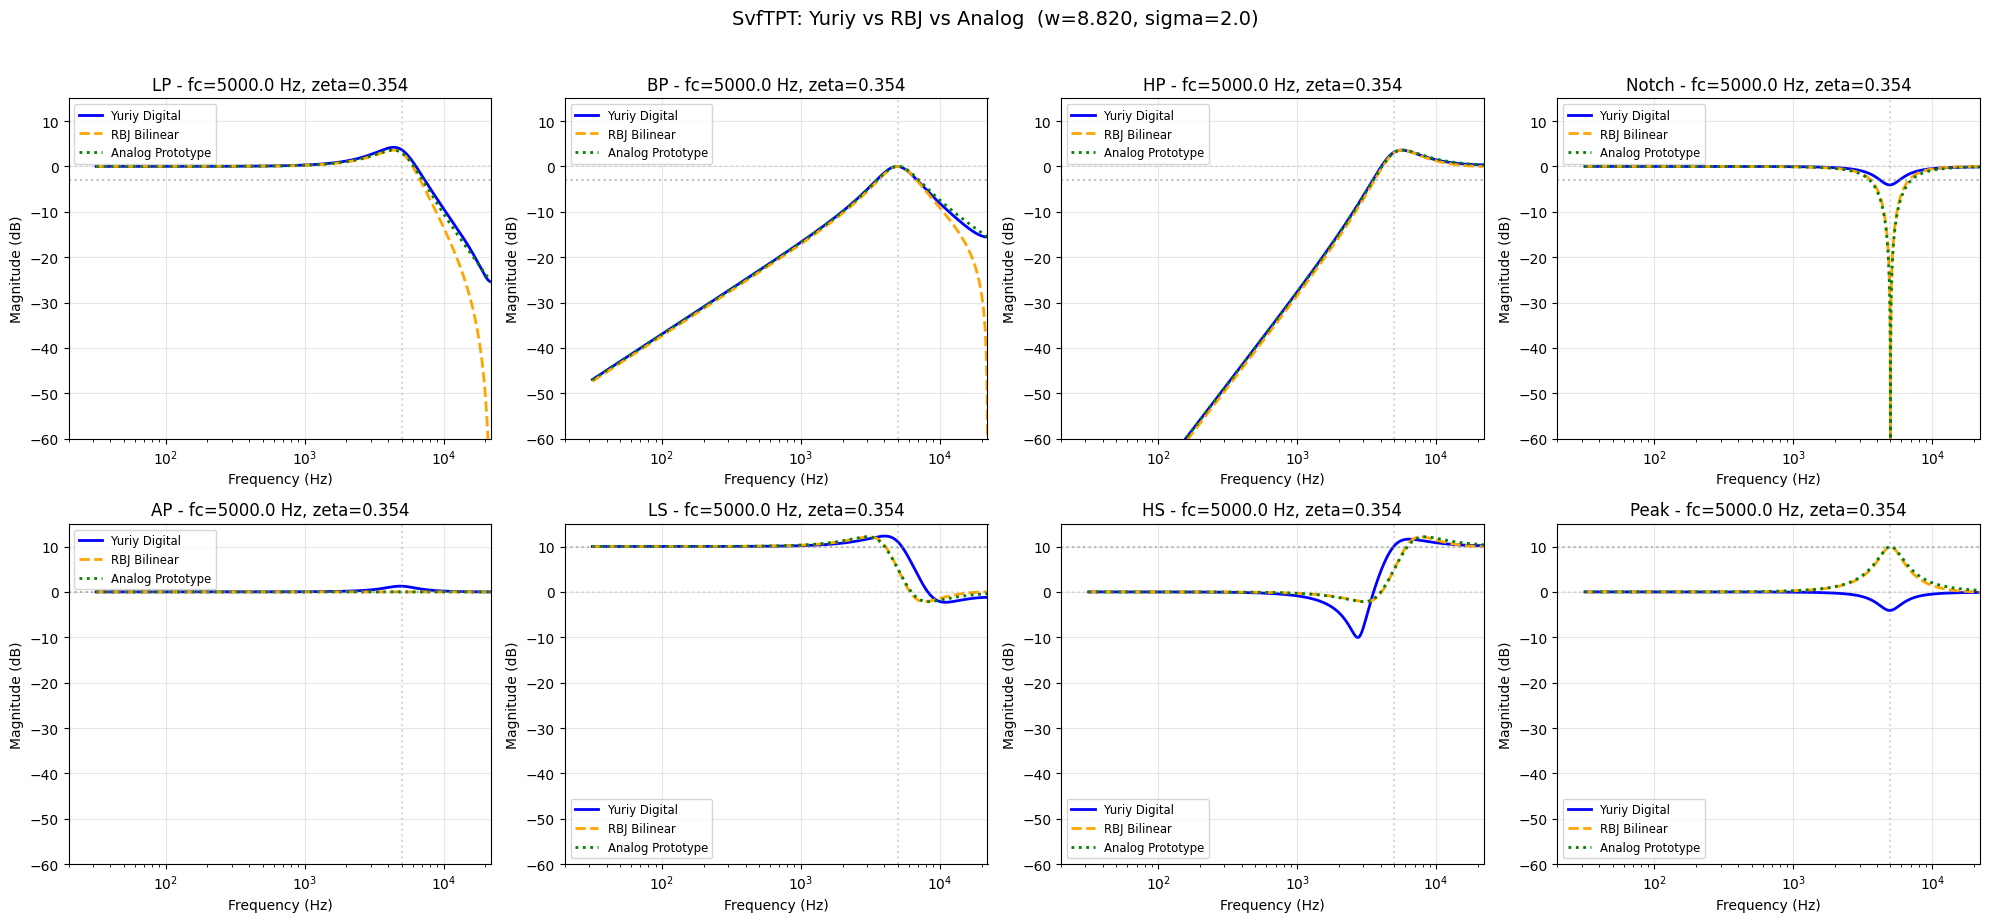

In [ ]:
def get_rbj_coefficients(filter_type, fc, fs, zeta=1.0/np.sqrt(2), gain_db=10.0):
    w0 = 2.0 * np.pi * fc / fs
    cos_w0 = np.cos(w0)
    sin_w0 = np.sin(w0)
    Q = 1.0 / (2.0 * zeta)
    alpha = sin_w0 / (2.0 * Q)
    A = 10.0 ** (gain_db / 40.0)

    if filter_type.lower() in ["low pass", "lp"]:
        b0 = (1.0 - cos_w0) / 2.0; b1 = 1.0 - cos_w0; b2 = (1.0 - cos_w0) / 2.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["high pass", "hp"]:
        b0 = (1.0 + cos_w0) / 2.0; b1 = -(1.0 + cos_w0); b2 = (1.0 + cos_w0) / 2.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band pass", "bp"]:
        b0 = alpha; b1 = 0.0; b2 = -alpha
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band stop", "notch"]:
        b0 = 1.0; b1 = -2.0 * cos_w0; b2 = 1.0
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["all pass", "ap"]:
        b0 = 1.0 - alpha; b1 = -2.0 * cos_w0; b2 = 1.0 + alpha
        a0 = 1.0 + alpha; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha
    elif filter_type.lower() in ["band shelf", "peak"]:
        b0 = 1.0 + alpha * A; b1 = -2.0 * cos_w0; b2 = 1.0 - alpha * A
        a0 = 1.0 + alpha / A; a1 = -2.0 * cos_w0; a2 = 1.0 - alpha / A
    elif filter_type.lower() in ["low shelf", "ls"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = 2.0 * A * ((A - 1.0) - (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = -2.0 * ((A - 1.0) + (A + 1.0) * cos_w0)
        a2 = (A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    elif filter_type.lower() in ["high shelf", "hs"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = -2.0 * A * ((A - 1.0) + (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = 2.0 * ((A - 1.0) - (A + 1.0) * cos_w0)
        a2 = (A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")

    b = [b0 / a0, b1 / a0, b2 / a0]
    a = [1.0, a1 / a0, a2 / a0]
    return b, a

def get_analogue_magnitude_response(filter_type, f, fc, zeta=1.0/np.sqrt(2), gain_db=10.0):
    s = 1j * (f / fc)
    g = 10 ** (gain_db / 20.0)
    sg = np.sqrt(g)
    fg = np.sqrt(sg)

    if filter_type.lower() in ["low pass", "lp"]:
        h_s = 1.0 / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["high pass", "hp"]:
        h_s = s**2 / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band pass", "bp"]:
        h_s = 2*zeta*s / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band stop", "notch"]:
        h_s = (s**2 + 1.0) / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["all pass", "ap"]:
        h_s = (s**2 - 2*zeta*s + 1.0) / (s**2 + 2*zeta*s + 1.0)
    elif filter_type.lower() in ["band shelf", "peak"]:
        h_s = (s**2 + 2*zeta*sg*s + 1.0) / (s**2 + 2*zeta/sg*s + 1.0)
    elif filter_type.lower() in ["high shelf", "hs"]:
        h_s = sg * (sg*s**2 + fg*2*zeta*s + 1.0) / (s**2 + fg*2*zeta*s + sg)
    elif filter_type.lower() in ["low shelf", "ls"]:
        h_s = sg * (s**2 + fg*2*zeta*s + sg) / (sg*s**2 + fg*2*zeta*s + 1.0)
    else:
        return np.ones_like(f)

    return np.abs(h_s)


# ============================================================
# Yuriy 映射函数
# ============================================================

def sign(x):
    if x > 0.0:
        return 1.0
    else:
        return -1.0

def yuriy_nu_kappa(w, sigma, zeta):
    """计算 ν = sqrt(w⁴ + 2·w²·σ²·(2ζ²-1) + σ⁴)  和  κ = w²·(2ζ²-1) + σ²"""
    nu = np.sqrt(w**4 + 2 * w**2 * sigma**2 * (2 * zeta**2 - 1) + sigma**4)
    kappa = w**2 * (2 * zeta**2 - 1) + sigma**2
    return nu, kappa

def yuriy_g_zeta(nu, kappa):
    """计算 g_z = π / sqrt(ν)  和  ζ_z = sqrt(ν+κ) / sqrt(2·ν)"""
    g_z = np.pi / np.sqrt(nu)
    zeta_z = np.sqrt(nu + kappa) / np.sqrt(2 * nu)
    return g_z, zeta_z

def yuriy_m0z_m1z_m2z(m0, m1, m2, sigma, w, v):
    """计算数字域的混合系数 m0z, m1z, m2z
    """
    m0z = m0
    m1z = sign(m1) * np.sqrt(w**2 * m1**2 + m0**2*sigma**4) / np.sqrt(v)
    m2z = sign(m2) * np.sqrt((m0**2*sigma**4+m2**2*w**4+w**2*sigma**2*(m1**2-2*m0*m2))) / v
    return m0z, m1z, m2z

def yuriy_biquad_coeffs(g_z, zeta_z, m0z, m1z, m2z):
    """从 Yuriy 参数计算数字双二阶系数
       H(z⁻¹) = (b0 + b1·z⁻¹ + b2·z⁻²) / (1 + a1·z⁻¹ + a2·z⁻²)
       其中 d = 1 / (1 + 2·ζ_z·g_z + g_z²)
    """
    d = 1.0 / (1.0 + 2 * zeta_z * g_z + g_z * g_z)
    a = [1.0, (2 * g_z**2 - 2) * d, (g_z**2 - 2 * zeta_z * g_z + 1) * d]
    b = [(g_z**2 * m0z + g_z * m1z + m2z) * d,
         (2 * g_z**2 * m0z - 2 * m2z) * d,
         (g_z**2 * m0z - g_z * m1z + m2z) * d]
    return b, a


# ============================================================
# 统一对比: Yuriy 数字 SvfTPT vs RBJ 双二阶 vs 模拟原型
# ============================================================

fs = 44100.0
fc = 5000.0
zeta = 1.0 / np.sqrt(8)

# ---- Yuriy 参数映射 ----
w_y = fs / fc
sigma_y = 2.0
gain_db_shelf = 10.0
gain_lin = 10.0 ** (gain_db_shelf / 20.0)  # 线性增益

nu_y, kappa_y = yuriy_nu_kappa(w_y, sigma_y, zeta)
g_z, zeta_z = yuriy_g_zeta(nu_y, kappa_y)

print(f"w={w_y:.4f},  sigma={sigma_y}")
print(f"g_z = {g_z:.6f}  (bilinear g = {np.tan(np.pi*fc/fs):.6f})")
print(f"zeta_z = {zeta_z:.6f}  (analog zeta = {zeta:.6f})")

# ---- 八种滤波器类型的 Yuriy 系数 ----
# (m0, m1, m2, 标签, RBJ 类型, 模拟类型, [增益])
# shelf/peak 的 m0,m1,m2 近似匹配 DC/HF 增益，中频会有偏差
filter_specs = [
    (1, 0,          0,              "LP",    "low pass",    "low pass",    False),
    (0, 2*zeta,     0,              "BP",    "band pass",   "band pass",   False),
    (0, 0,          1,              "HP",    "high pass",   "high pass",   False),
    (1, 0,          1,              "Notch", "band stop",   "notch",       False),
    (1, -2*zeta,    1,              "AP",    "all pass",    "all pass",    False),
    (gain_lin, 0,   1,              "LS",    "low shelf",   "low shelf",   True),
    (1, 0,          gain_lin,       "HS",    "high shelf",  "high shelf",  True),
    (1, 0,          1,              "Peak",  "band shelf",  "peak",        True),
]

n_filters = len(filter_specs)
bs_y_list = []
a_y = None
labels = []
rbj_types = []
analog_types = []
use_gain = []

for m0, m1, m2, label, rbj_t, ana_t, need_gain in filter_specs:
    m0z, m1z, m2z = yuriy_m0z_m1z_m2z(m0, m1, m2, sigma_y, w_y, nu_y)
    b, a = yuriy_biquad_coeffs(g_z, zeta_z, m0z, m1z, m2z)
    bs_y_list.append(b)
    if a_y is None:
        a_y = a
    labels.append(label)
    rbj_types.append(rbj_t)
    analog_types.append(ana_t)
    use_gain.append(need_gain)
    print(f"{label}: m0z={m0z:.6f}, m1z={m1z:.6f}, m2z={m2z:.6f}")

# ---- 频响计算 ----
freqs = np.logspace(1.5, np.log10(fs / 2), 2048)
w_norm, _ = signal.freqz([1], [1], worN=freqs, fs=fs)

# ---- 绘图 (2 行, 4 列) ----
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes_flat = axes.flatten()

for col in range(n_filters):
    ax = axes_flat[col]
    g_db = gain_db_shelf if use_gain[col] else 0.0

    # Yuriy 数字
    _, h_yuriy = signal.freqz(bs_y_list[col], a_y, worN=freqs, fs=fs)
    # RBJ 双二阶
    b_rbj, a_rbj = get_rbj_coefficients(rbj_types[col], fc, fs, zeta, gain_db=g_db)
    _, h_rbj = signal.freqz(b_rbj, a_rbj, worN=freqs, fs=fs)
    # 模拟原型
    h_ana = get_analogue_magnitude_response(analog_types[col], w_norm, fc, zeta=zeta, gain_db=g_db)

    ax.semilogx(w_norm, 20 * np.log10(np.maximum(np.abs(h_yuriy), 1e-5)),
                'b-', label='Yuriy Digital', linewidth=2)
    ax.semilogx(w_norm, 20 * np.log10(np.maximum(np.abs(h_rbj), 1e-5)),
                'orange', linestyle='--', label='RBJ Bilinear', linewidth=2)
    ax.semilogx(w_norm, 20 * np.log10(np.maximum(h_ana, 1e-15)),
                'green', linestyle=':', label='Analog Prototype', linewidth=2)

    ref_db = 0 if col == 4 else -3  # AP→0dB, others→-3dB
    if use_gain[col]:
        ref_db = gain_db_shelf  # shelf/peak 参考线在增益值
    ax.axhline(ref_db, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.2)
    ax.axvline(fc, color='gray', linestyle=':', alpha=0.3)
    ax.set_xscale('log')
    ax.set_xlim(20, fs / 2)
    ax.set_ylim(-60, 15)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{labels[col]} - fc={fc} Hz, zeta={zeta:.3f}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.legend(fontsize='small')

fig.suptitle(f'SvfTPT: Yuriy vs RBJ vs Analog  (w={w_y:.3f}, sigma={sigma_y})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
